In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import os
import time

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3


In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip -q human+activity+recognition+using+smartphones.zip

In [ ]:
import os

# List the contents of the current directory to find the actual dataset path
print(os.listdir('.'))

# The original line caused an error because 'UCI HAR Dataset' was not found
print(os.listdir("UCI HAR Dataset"))

['.config', 'UCI HAR Dataset.names', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.zip', 'sample_data']


FileNotFoundError: [Errno 2] No such file or directory: 'UCI HAR Dataset'

In [ ]:
import zipfile
import os

zip_file = "UCI HAR Dataset.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("."))

['.config', 'UCI HAR Dataset.names', 'UCI HAR Dataset', '__MACOSX', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.zip', 'sample_data']


In [ ]:
print(os.listdir("UCI HAR Dataset"))

['features_info.txt', 'train', '.DS_Store', 'features.txt', 'test', 'activity_labels.txt', 'README.txt']


In [ ]:
print(os.listdir("UCI HAR Dataset/train/Inertial Signals"))

['body_acc_x_train.txt', 'body_gyro_x_train.txt', 'total_acc_z_train.txt', 'total_acc_y_train.txt', 'body_acc_z_train.txt', 'body_gyro_z_train.txt', 'body_gyro_y_train.txt', 'total_acc_x_train.txt', 'body_acc_y_train.txt']


In [ ]:
import numpy as np
import os

base_path = "UCI HAR Dataset"

# --------------------------------------------------
# Function to load the 3-axis signals from one folder
# --------------------------------------------------

def load_signals(folder):

    signal_names = [
        "body_acc_x",
        "body_acc_y",
        "body_acc_z",
        "body_gyro_x",
        "body_gyro_y",
        "body_gyro_z",
        "total_acc_x",
        "total_acc_y",
        "total_acc_z"
    ]

    signals = []

    for signal in signal_names:

        file_path = os.path.join(
            base_path,
            folder,
            "Inertial Signals",
            signal + "_" + folder + ".txt"
        )

        data = np.loadtxt(file_path)
        signals.append(data)

    # Each signal has shape:
    # (number_of_samples, 128)

    # Stack the 9 signals
    X = np.stack(signals, axis=2)

    return X


# Load training data
X_train_full = load_signals("train")

# Load testing data
X_test = load_signals("test")

print("Training shape:", X_train_full.shape)
print("Testing shape:", X_test.shape)

Training shape: (7352, 128, 9)
Testing shape: (2947, 128, 9)


In [ ]:
# Load training labels
y_train_full = np.loadtxt(
    "UCI HAR Dataset/train/y_train.txt"
).astype(int)

# Load test labels
y_test = np.loadtxt(
    "UCI HAR Dataset/test/y_test.txt"
).astype(int)

print("Training labels shape:", y_train_full.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (7352,)
Testing labels shape: (2947,)


In [ ]:
import numpy as np

# Load training labels
y_train = np.loadtxt(
    "UCI HAR Dataset/train/y_train.txt",
    dtype=int
)

print("Training labels shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))

Training labels shape: (7352,)
Unique labels: [1 2 3 4 5 6]


In [ ]:
y_train = y_train - 1

print("Unique labels after conversion:", np.unique(y_train))

Unique labels after conversion: [0 1 2 3 4 5]


In [ ]:
activity_names = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(activity_names[label], ":", count)

WALKING : 1226
WALKING UPSTAIRS : 1073
WALKING DOWNSTAIRS : 986
SITTING : 1286
STANDING : 1374
LAYING : 1407


In [ ]:
# Convert labels from 1-6 to 0-5
y_train_full = y_train_full - 1

# Activity names
activity_names = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Count each activity
unique, counts = np.unique(y_train_full, return_counts=True)

for label, count in zip(unique, counts):
    print(activity_names[label], ":", count)

WALKING : 1226
WALKING UPSTAIRS : 1073
WALKING DOWNSTAIRS : 986
SITTING : 1286
STANDING : 1374
LAYING : 1407


In [ ]:
unique, counts = np.unique(y_train_full, return_counts=True)

for label, count in zip(unique, counts):
    print(activity_names[label], ":", count)

WALKING : 1226
WALKING UPSTAIRS : 1073
WALKING DOWNSTAIRS : 986
SITTING : 1286
STANDING : 1374
LAYING : 1407


In [ ]:
selected_indices = []

for label in range(1, 7):

    indices = np.where(y_train_full == label)[0]

    # Take maximum 500 samples from each class
    selected_indices.extend(indices[:500])

selected_indices = np.array(selected_indices)

X = X_train_full[selected_indices]
y = y_train_full[selected_indices]

print("Selected data shape:", X.shape)
print("Selected labels shape:", y.shape)

Selected data shape: (2500, 128, 9)
Selected labels shape: (2500,)


In [ ]:
y = y - 1
y_test = y_test - 1

print("Training labels:", np.unique(y))
print("Testing labels:", np.unique(y_test))

Training labels: [0 1 2 3 4]
Testing labels: [0 1 2 3 4 5]


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (1750, 128, 9)
Validation: (750, 128, 9)
Testing: (2947, 128, 9)


In [ ]:
# Calculate mean and standard deviation from training data

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

# Avoid division by zero
std = std + 1e-8

# Normalize training data
X_train = (X_train - mean) / std

# Normalize validation data
X_val = (X_val - mean) / std

# Normalize test data
X_test = (X_test - mean) / std

print("Training mean:", X_train.mean())
print("Training std:", X_train.std())

Training mean: 1.0762466755540883e-15
Training std: 0.9999999570177481


In [ ]:
print("Input tensor shape:")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

print()
print("Number of classes:", 6)
print("Features per time step:", 9)
print("Sequence length:", 128)

Input tensor shape:
Training   : (1750, 128, 9)
Validation : (750, 128, 9)
Testing    : (2947, 128, 9)

Number of classes: 6
Features per time step: 9
Sequence length: 128


In [ ]:
print("Training class distribution:")

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(label, ":", count)

Training class distribution:
0 : 350
1 : 350
2 : 350
3 : 350
4 : 350


Labels: [0 1 2 3 4 5]
Counts: [1226 1073  986 1286 1374 1407]


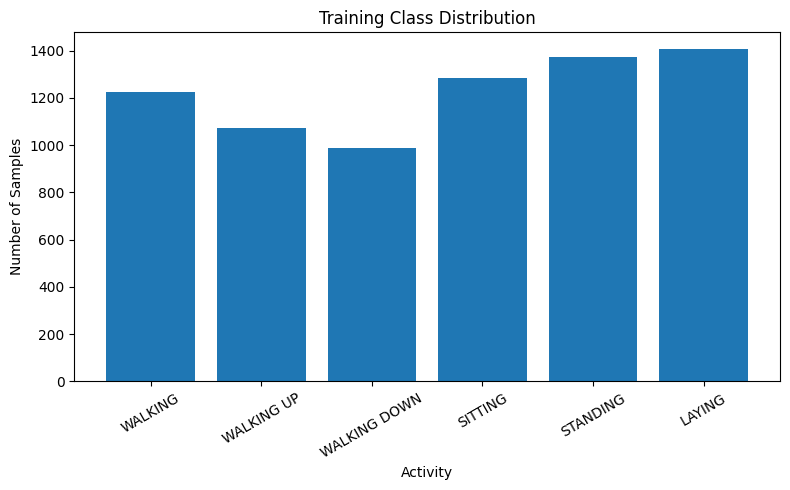

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Activity names
labels = [
    "WALKING",
    "WALKING UP",
    "WALKING DOWN",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Count samples for each class
unique, counts = np.unique(y_train_full, return_counts=True)

print("Labels:", unique)
print("Counts:", counts)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(labels, counts)

plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.title("Training Class Distribution")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("Unique labels in y_train:", np.unique(y_train))

Unique labels in y_train: [0 1 2 3 4]


Available classes: [0 1 2 3 4]


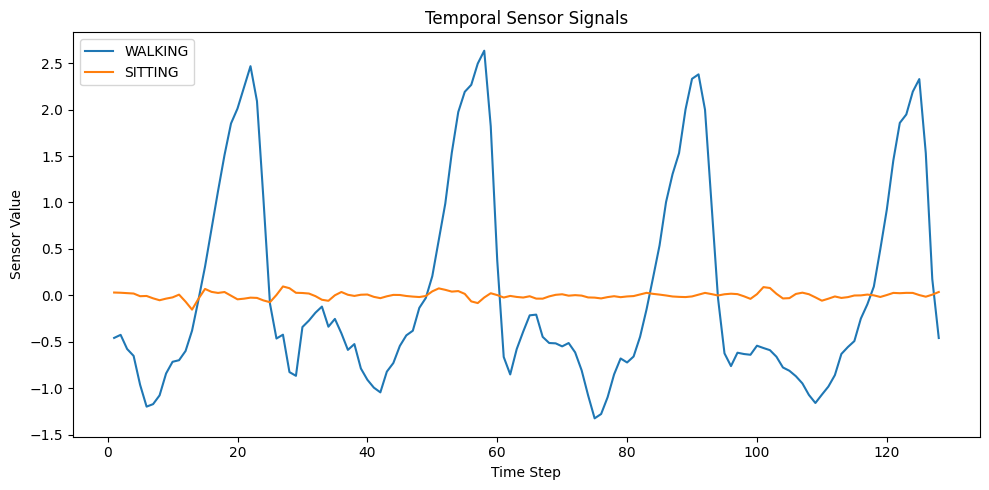

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Check available classes
print("Available classes:", np.unique(y_train))

# Find one sample from available classes
sample_walking = X_train[np.where(y_train == 0)[0][0]]
sample_sitting = X_train[np.where(y_train == 3)[0][0]]

time_steps = np.arange(1, 129)

plt.figure(figsize=(10, 5))

plt.plot(time_steps, sample_walking[:, 0], label="WALKING")
plt.plot(time_steps, sample_sitting[:, 0], label="SITTING")

plt.xlabel("Time Step")
plt.ylabel("Sensor Value")
plt.title("Temporal Sensor Signals")
plt.legend()

plt.tight_layout()
plt.show()

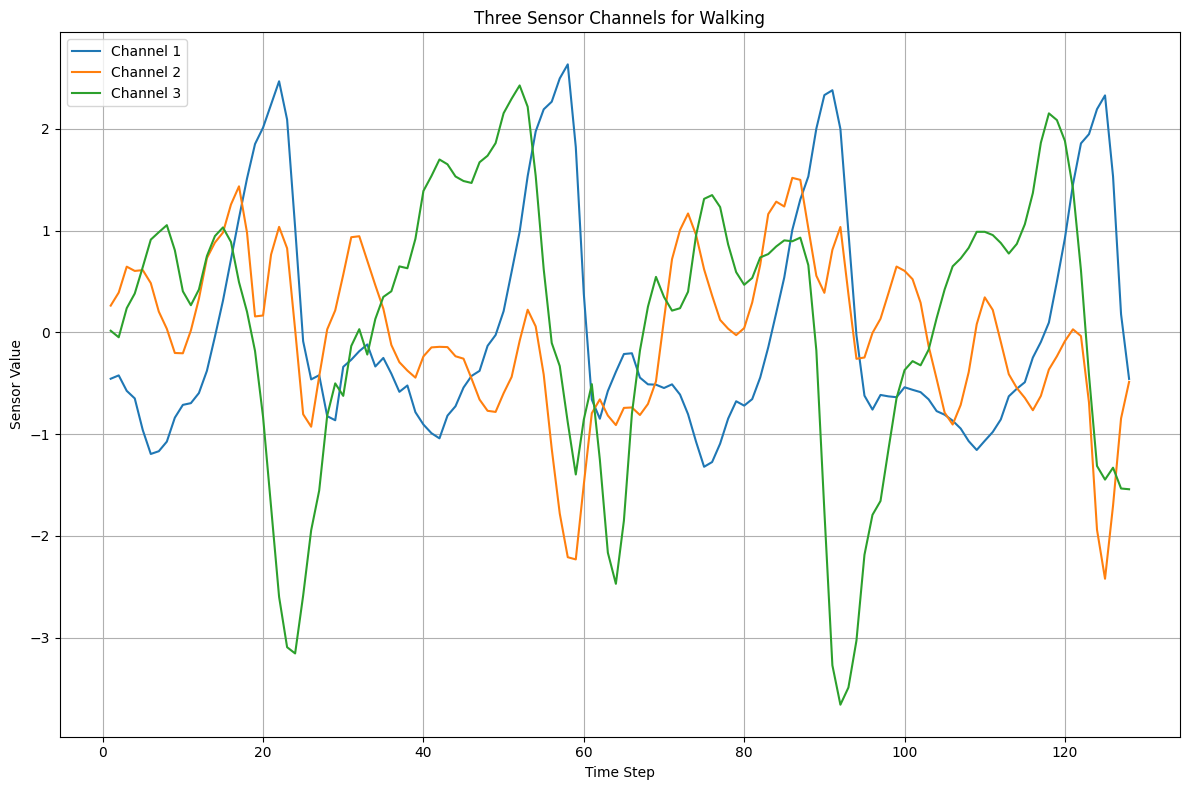

In [ ]:
plt.figure(figsize=(12, 8))

channels = [0, 1, 2]

for channel in channels:

    plt.plot(
        time_steps,
        sample_walking[:, channel],
        label=f"Channel {channel + 1}"
    )

plt.xlabel("Time Step")
plt.ylabel("Sensor Value")
plt.title("Three Sensor Channels for Walking")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0

Wx = 0.5
Wh = 0.8
b = 0.1

# Calculate h1
h1 = np.tanh(Wx * x1 + Wh * h0 + b)

# Calculate h2
h2 = np.tanh(Wx * x2 + Wh * h1 + b)

# Calculate h3
h3 = np.tanh(Wx * x3 + Wh * h2 + b)

print("h1 =", h1)
print("h2 =", h2)
print("h3 =", h3)

h1 = 0.3363755443363322
h2 = 0.6163517827505027
h3 = 0.5999579155496113


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense

rnn_model = Sequential([
    SimpleRNN(32, input_shape=(128, 9)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("RNN model compiled successfully.")

RNN model compiled successfully.


In [ ]:
from tensorflow.keras.optimizers import Adam

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("RNN model compiled successfully.")

RNN model compiled successfully.


In [ ]:
import time

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

rnn_training_time = time.time() - start_time

print("RNN training time:", rnn_training_time, "seconds")

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.4223 - loss: 1.3669 - val_accuracy: 0.5640 - val_loss: 1.0832
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6029 - loss: 0.9702 - val_accuracy: 0.7240 - val_loss: 0.8055
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6800 - loss: 0.7744 - val_accuracy: 0.6587 - val_loss: 0.9145
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6691 - loss: 0.7178 - val_accuracy: 0.7440 - val_loss: 0.6166
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7154 - loss: 0.6376 - val_accuracy: 0.7600 - val_loss: 0.6054
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7669 - loss: 0.5662 - val_accuracy: 0.7600 - val_loss: 0.4974
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7989 - loss: 0.5100 - val_accuracy: 0.8240 - val_loss: 0.5448
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8331 - loss: 0.4546 - val_accuracy: 0.8720 - v

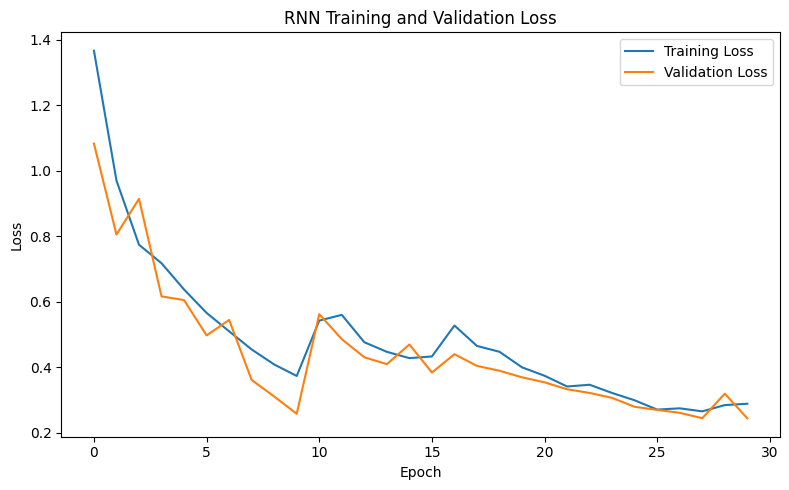

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

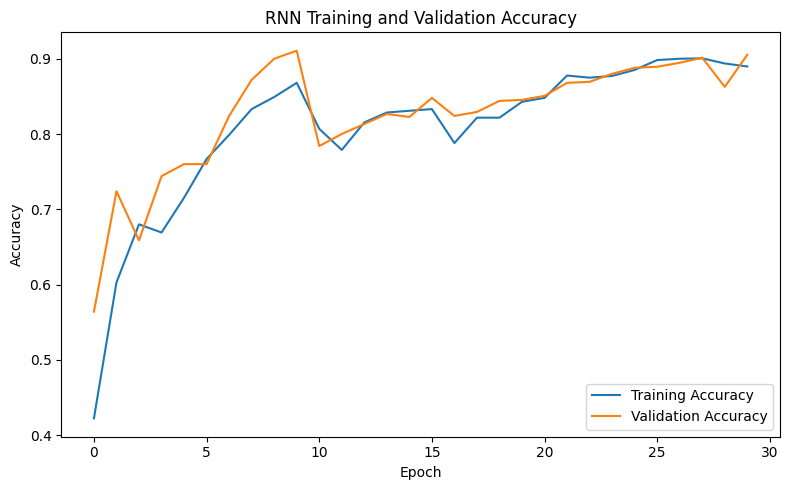

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("RNN Test Accuracy:", test_accuracy)
print("RNN Test Loss:", test_loss)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1520 - loss: 7.6085
RNN Test Accuracy: 0.15201900899410248
RNN Test Loss: 7.608543395996094


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Predict classes
y_pred_rnn = rnn_model.predict(X_test)

y_pred_rnn = np.argmax(y_pred_rnn, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred_rnn)
precision = precision_score(y_test, y_pred_rnn, average="macro")
recall = recall_score(y_test, y_pred_rnn, average="macro")
f1 = f1_score(y_test, y_pred_rnn, average="macro")

print("RNN Accuracy :", accuracy)
print("RNN Precision:", precision)
print("RNN Recall   :", recall)
print("RNN F1 Score :", f1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
RNN Accuracy : 0.15201900237529692
RNN Precision: 0.10282770450081809
RNN Recall   : 0.1514168500697415
RNN F1 Score : 0.12165940018571036


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


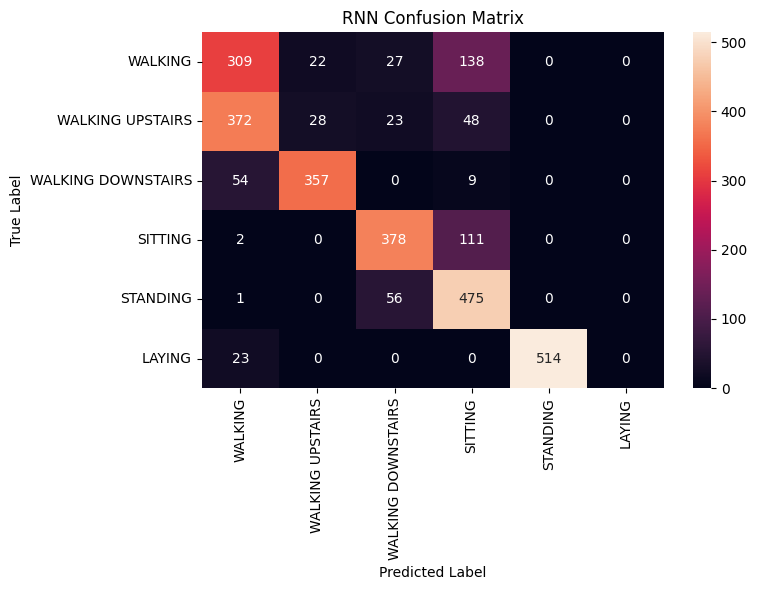

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RNN Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
print("RNN Trainable Parameters:",
      rnn_model.count_params())

RNN Trainable Parameters: 1974


In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(32, input_shape=(128, 9)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [ ]:
import time

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

lstm_training_time = time.time() - start_time

print("LSTM Training Time:",
      lstm_training_time,
      "seconds")

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4583 - loss: 1.5887 - val_accuracy: 0.6067 - val_loss: 1.2579
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6063 - loss: 1.0182 - val_accuracy: 0.8053 - val_loss: 0.6949
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7509 - loss: 0.6229 - val_accuracy: 0.8053 - val_loss: 0.4927
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7720 - loss: 0.4786 - val_accuracy: 0.8173 - val_loss: 0.4242
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7983 - loss: 0.4231 - val_accuracy: 0.8440 - val_loss: 0.3833
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8314 - loss: 0.3734 - val_accuracy: 0.8907 - val_loss: 0.3394
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8949 - loss: 0.2937 - val_accuracy: 0.9267 - val_loss: 0.2137
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8909 - loss: 0.2815 - val_accuracy: 0.8867 - v

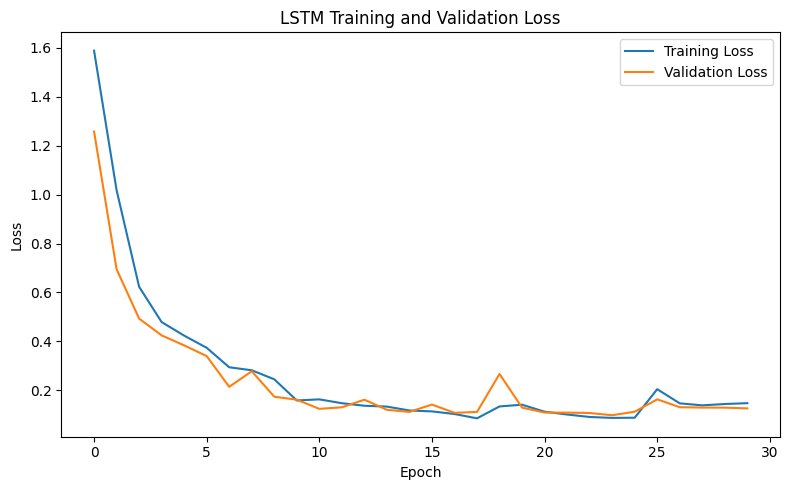

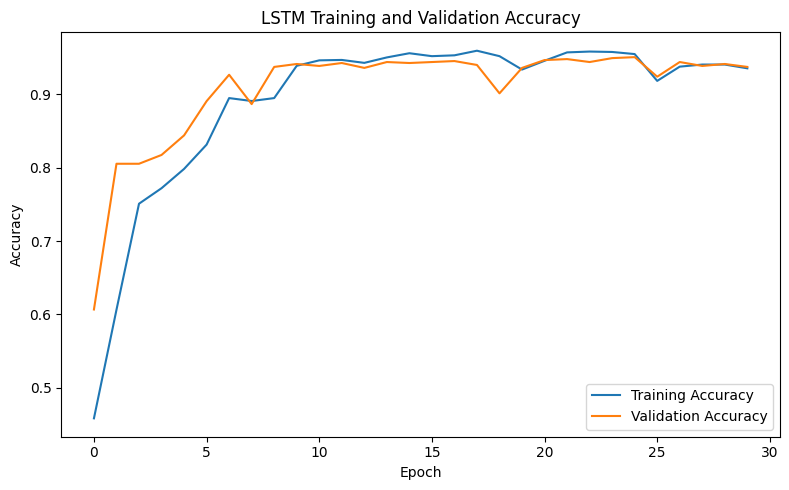

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1941 - loss: 7.3426
LSTM Test Accuracy: 0.1940956860780716
LSTM Test Loss: 7.3426194190979


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



LSTM Results
----------------------
Accuracy : 0.1940956860780716
Precision: 0.12184751598622724
Recall   : 0.19334233180096796
F1 Score : 0.14885576113887553


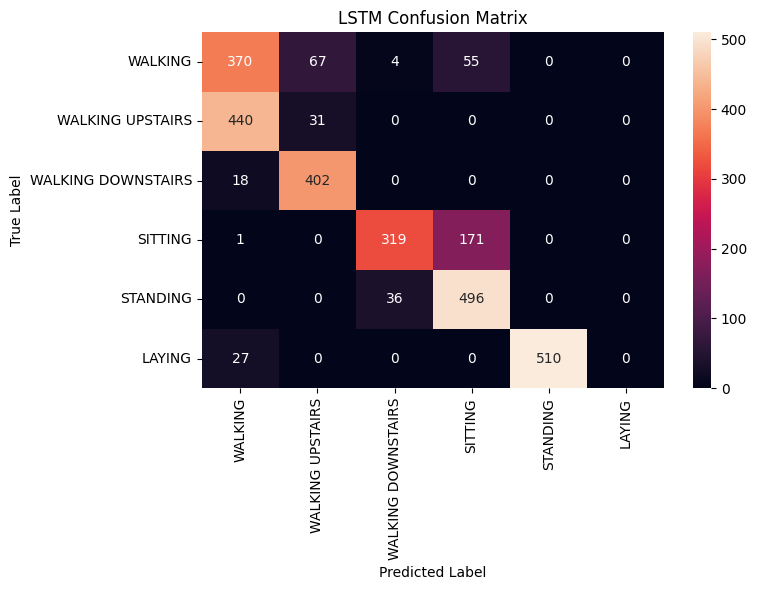

LSTM Trainable Parameters: 6006


In [ ]:
# -------------------------------
# Task 26: Loss Plot
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------
# Task 27: Accuracy Plot
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------
# Task 28: Test Evaluation
# -------------------------------

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)


# -------------------------------
# Task 29: Predictions
# -------------------------------

y_pred_lstm = lstm_model.predict(
    X_test,
    verbose=0
)

y_pred_lstm = np.argmax(
    y_pred_lstm,
    axis=1
)


# -------------------------------
# Task 30: Metrics
# -------------------------------

lstm_precision = precision_score(
    y_test,
    y_pred_lstm,
    average="macro"
)

lstm_recall = recall_score(
    y_test,
    y_pred_lstm,
    average="macro"
)

lstm_f1 = f1_score(
    y_test,
    y_pred_lstm,
    average="macro"
)

print("\nLSTM Results")
print("----------------------")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)


# -------------------------------
# Task 31: Confusion Matrix
# -------------------------------

cm_lstm = confusion_matrix(
    y_test,
    y_pred_lstm
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM Confusion Matrix")

plt.tight_layout()
plt.show()


# Number of parameters
print(
    "LSTM Trainable Parameters:",
    lstm_model.count_params()
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4611 - loss: 1.5535 - val_accuracy: 0.5467 - val_loss: 1.2683
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6074 - loss: 1.0966 - val_accuracy: 0.6987 - val_loss: 0.8785
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7194 - loss: 0.7372 - val_accuracy: 0.7653 - val_loss: 0.5805
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8080 - loss: 0.5060 - val_accuracy: 0.8253 - val_loss: 0.4596
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8474 - loss: 0.4172 - val_accuracy: 0.8773 - val_loss: 0.3840
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8663 - loss: 0.3510 - val_accuracy: 0.8907 - val_loss: 0.3151
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9069 - loss: 0.2825 - val_accuracy: 0.9240 - val_loss: 0.2503
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9320 - loss: 0.2184 - val_accuracy: 0.9440 - v

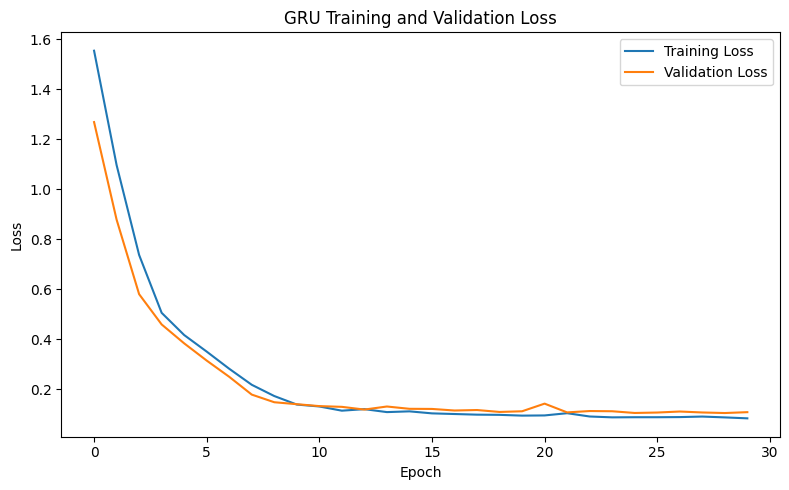

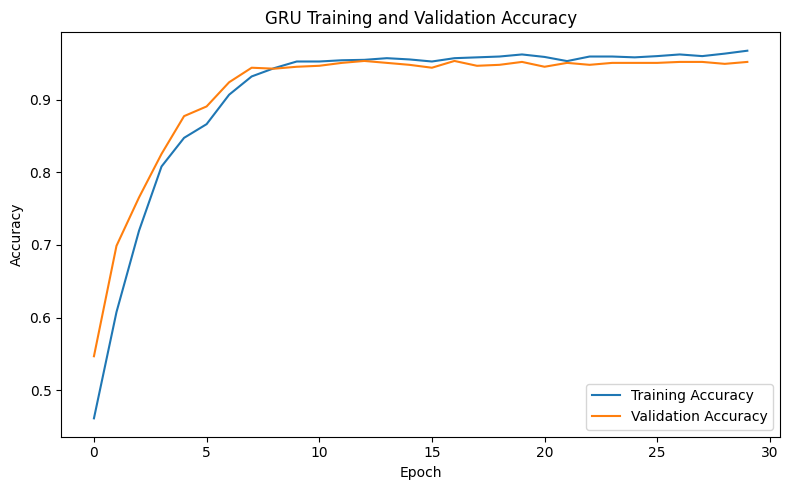

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1917 - loss: 8.7819
GRU Test Accuracy: 0.1917203962802887
GRU Test Loss: 8.78187084197998


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



GRU Results
----------------------
Accuracy : 0.1917203962802887
Precision: 0.11159422168837686
Recall   : 0.1905507691929543
F1 Score : 0.13874150118565404


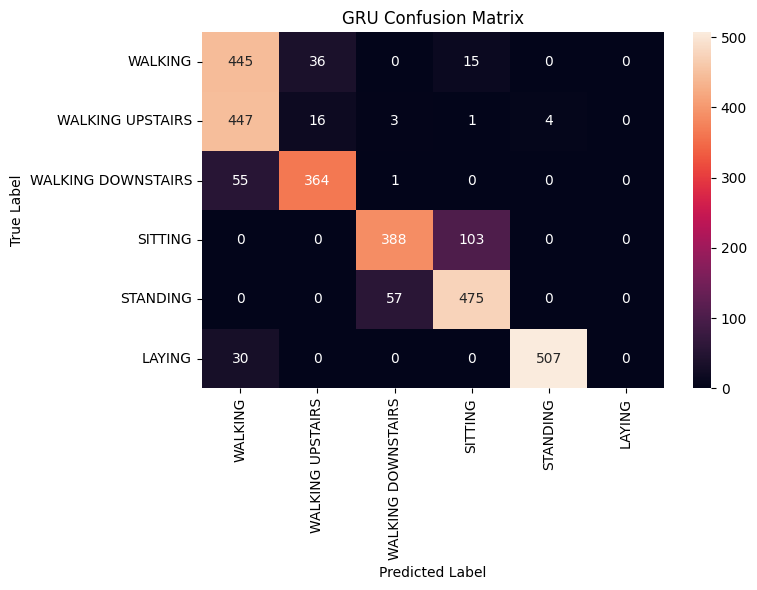

GRU Trainable Parameters: 4758
  Model  Accuracy  Precision    Recall  Macro F1  Parameters  \
0   RNN  0.152019   0.102828  0.151417  0.121659        1974   
1  LSTM  0.194096   0.121848  0.193342  0.148856        6006   
2   GRU  0.191720   0.111594  0.190551  0.138742        4758   

   Training Time (s)  
0          28.956584  
1          31.092924  
2          43.610037  


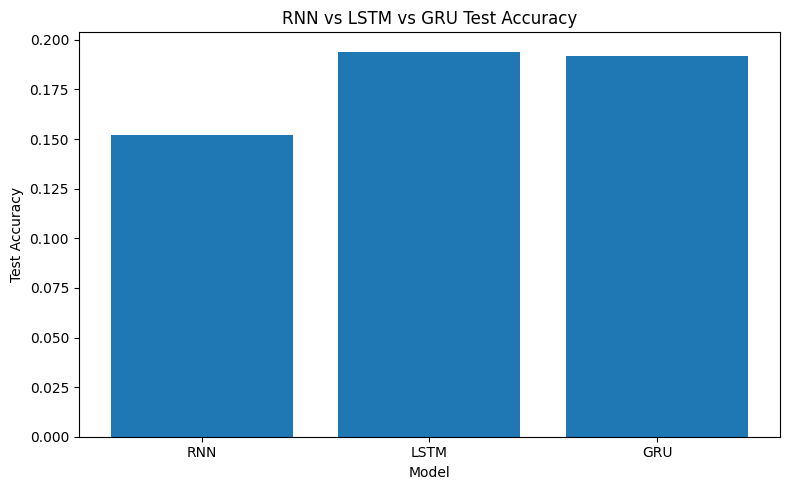

In [ ]:
# ==========================================
# TASKS 32-43: GRU + MODEL COMPARISON
# ==========================================

from tensorflow.keras.layers import GRU


# -------------------------------
# Task 32: Create GRU model
# -------------------------------

gru_model = Sequential([
    GRU(32, input_shape=(128, 9)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

gru_model.summary()


# -------------------------------
# Task 33: Compile
# -------------------------------

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# -------------------------------
# Task 34: Train GRU
# -------------------------------

start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

gru_training_time = time.time() - start_time

print(
    "GRU Training Time:",
    gru_training_time,
    "seconds"
)


# -------------------------------
# Task 35: Loss Plot
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------
# Task 36: Accuracy Plot
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------
# Task 37: Test Evaluation
# -------------------------------

gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("GRU Test Accuracy:", gru_accuracy)
print("GRU Test Loss:", gru_loss)


# -------------------------------
# Task 38: Predictions
# -------------------------------

y_pred_gru = gru_model.predict(
    X_test,
    verbose=0
)

y_pred_gru = np.argmax(
    y_pred_gru,
    axis=1
)


# -------------------------------
# Task 39: Metrics
# -------------------------------

gru_precision = precision_score(
    y_test,
    y_pred_gru,
    average="macro"
)

gru_recall = recall_score(
    y_test,
    y_pred_gru,
    average="macro"
)

gru_f1 = f1_score(
    y_test,
    y_pred_gru,
    average="macro"
)

print("\nGRU Results")
print("----------------------")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)


# -------------------------------
# Task 40: Confusion Matrix
# -------------------------------

cm_gru = confusion_matrix(
    y_test,
    y_pred_gru
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU Confusion Matrix")

plt.tight_layout()
plt.show()


# -------------------------------
# Task 41: Parameters
# -------------------------------

print(
    "GRU Trainable Parameters:",
    gru_model.count_params()
)


# -------------------------------
# Task 42: Comparison Table
# -------------------------------

import pandas as pd

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],

    "Accuracy": [
        accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Precision": [
        precision,
        lstm_precision,
        gru_precision
    ],

    "Recall": [
        recall,
        lstm_recall,
        gru_recall
    ],

    "Macro F1": [
        f1,
        lstm_f1,
        gru_f1
    ],

    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],

    "Training Time (s)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

print(results)


# -------------------------------
# Task 43: Accuracy Comparison
# -------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Test Accuracy")

plt.tight_layout()
plt.show()

32: (1750, 32, 9)
64: (1750, 64, 9)
128: (1750, 128, 9)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


F1 Score for 32 : 0.1331483261853146
F1 Score for 64 : 0.19990576575883798
F1 Score for 128: 0.10519558285934079
   Sequence Length  RNN Macro F1
0               32      0.133148
1               64      0.199906
2              128      0.105196


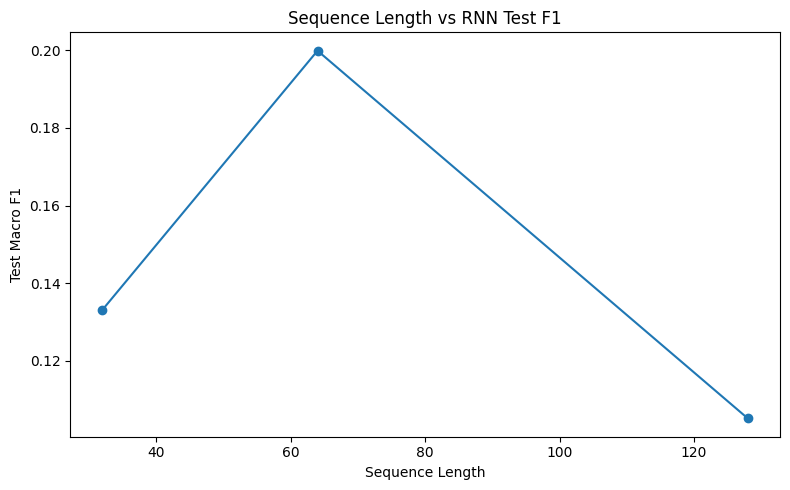

Input shape : (3000, 4)
Output shape: (3000, 4)

Example:
Input : [8 8 3 3]
Output: [3 3 8 8]
Training: (2400, 4)
Testing : (600, 4)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2129 - loss: 2.1616 - val_accuracy: 0.3177 - val_loss: 1.8666
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3595 - loss: 1.6695 - val_accuracy: 0.3729 - val_loss: 1.5331
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3941 - loss: 1.4463 - val_accuracy: 0.3906 - val_loss: 1.3973
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4085 - loss: 1.3370 - val_accuracy: 0.3984 - val_loss: 1.3112
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4241 - loss: 1.2529 - val_accuracy: 0.4318 - val_loss: 1.2255
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4714 - loss: 1.1525 - val_accuracy: 0.4833 - val_loss: 1.1111
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5365 - loss: 1.0311 - val_accuracy: 0.5568 - val_loss: 0.9979
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6086 - loss: 0.9102 - val_accuracy: 0.6286 - val

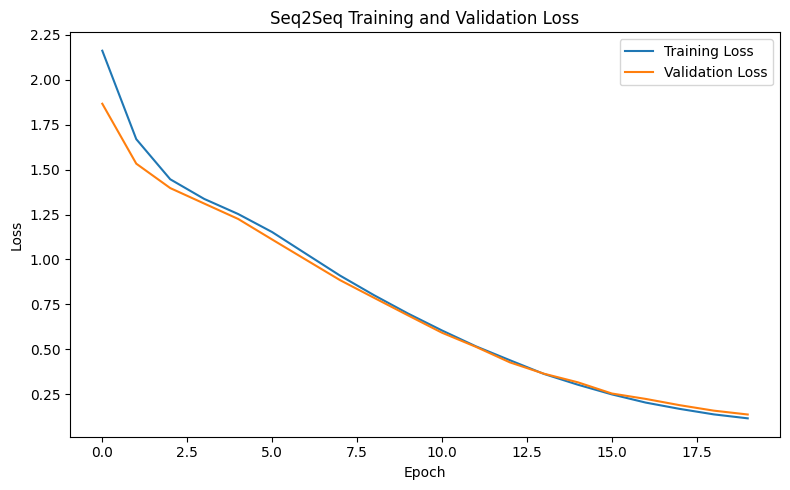

Example 1
Input    : [6 3 3 3]
Expected : [3 3 3 6]
Predicted: [3 3 3 6]

Example 2
Input    : [5 5 9 8]
Expected : [8 9 5 5]
Predicted: [8 9 5 5]

Example 3
Input    : [7 7 5 5]
Expected : [5 5 7 7]
Predicted: [5 5 7 7]

Example 4
Input    : [2 7 8 3]
Expected : [3 8 7 2]
Predicted: [3 8 7 2]

Example 5
Input    : [7 4 9 3]
Expected : [3 9 4 7]
Predicted: [3 9 4 7]

Token Accuracy: 0.9670833333333333
Sequence Accuracy: 0.885
  Model  Accuracy  Macro F1  Parameters  Training Time (s)
0   RNN  0.152019  0.121659        1974          28.956584
1  LSTM  0.194096  0.148856        6006          31.092924
2   GRU  0.191720  0.138742        4758          43.610037

Seq2Seq Results
-------------------------
Token Accuracy   : 0.9670833333333333
Sequence Accuracy: 0.885


In [ ]:
# ==========================================
# TASKS 44-67
# SEQUENCE LENGTH + SEQ2SEQ
# ==========================================

# ==========================================
# PART A: SEQUENCE LENGTH EXPERIMENT
# ==========================================

# Task 44

X_train_32 = X_train[:, :32, :]
X_val_32 = X_val[:, :32, :]
X_test_32 = X_test[:, :32, :]

X_train_64 = X_train[:, :64, :]
X_val_64 = X_val[:, :64, :]
X_test_64 = X_test[:, :64, :]

X_train_128 = X_train[:, :128, :]
X_val_128 = X_val[:, :128, :]
X_test_128 = X_test[:, :128, :]

print("32:", X_train_32.shape)
print("64:", X_train_64.shape)
print("128:", X_train_128.shape)


# ==========================================
# Task 45: Function
# ==========================================

def train_rnn_sequence_length(
    Xtr, ytr,
    Xv, yv,
    Xte, yte,
    length
):

    model = Sequential([
        SimpleRNN(
            32,
            input_shape=(length, 9)
        ),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        Xtr,
        ytr,
        validation_data=(Xv, yv),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    predictions = model.predict(
        Xte,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    score = f1_score(
        yte,
        predictions,
        average="macro"
    )

    return score


# ==========================================
# Task 46
# ==========================================

f1_32 = train_rnn_sequence_length(
    X_train_32,
    y_train,
    X_val_32,
    y_val,
    X_test_32,
    y_test,
    32
)

f1_64 = train_rnn_sequence_length(
    X_train_64,
    y_train,
    X_val_64,
    y_val,
    X_test_64,
    y_test,
    64
)

f1_128 = train_rnn_sequence_length(
    X_train_128,
    y_train,
    X_val_128,
    y_val,
    X_test_128,
    y_test,
    128
)

print("F1 Score for 32 :", f1_32)
print("F1 Score for 64 :", f1_64)
print("F1 Score for 128:", f1_128)


# ==========================================
# Task 47: Table
# ==========================================

sequence_results = pd.DataFrame({
    "Sequence Length": [32, 64, 128],
    "RNN Macro F1": [
        f1_32,
        f1_64,
        f1_128
    ]
})

print(sequence_results)


# ==========================================
# Task 48: Plot
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    [32, 64, 128],
    [f1_32, f1_64, f1_128],
    marker="o"
)

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1")
plt.title("Sequence Length vs RNN Test F1")

plt.tight_layout()
plt.show()


# ==========================================
# PART B: SEQ2SEQ
# ==========================================

# ==========================================
# Task 58: Create reversal dataset
# ==========================================

num_samples = 3000
sequence_length = 4
vocab_size = 10

X_seq = np.random.randint(
    1,
    vocab_size,
    size=(num_samples, sequence_length)
)

Y_seq = np.flip(
    X_seq,
    axis=1
)

print("Input shape :", X_seq.shape)
print("Output shape:", Y_seq.shape)

print("\nExample:")
print("Input :", X_seq[0])
print("Output:", Y_seq[0])


# ==========================================
# Task 59: Train/Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_seq_train, X_seq_test, Y_seq_train, Y_seq_test = train_test_split(
    X_seq,
    Y_seq,
    test_size=0.2,
    random_state=42
)

print("Training:", X_seq_train.shape)
print("Testing :", X_seq_test.shape)


# ==========================================
# Task 60: Seq2Seq Model
# ==========================================

from tensorflow.keras.layers import (
    Embedding,
    RepeatVector,
    TimeDistributed
)

seq2seq_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=32
    ),

    LSTM(64),

    RepeatVector(sequence_length),

    LSTM(
        64,
        return_sequences=True
    ),

    TimeDistributed(
        Dense(
            vocab_size,
            activation="softmax"
        )
    )
])

seq2seq_model.summary()


# ==========================================
# Task 61: Compile
# ==========================================

seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# Task 62: Train
# ==========================================

Y_seq_train_reshaped = np.expand_dims(
    Y_seq_train,
    axis=-1
)

Y_seq_test_reshaped = np.expand_dims(
    Y_seq_test,
    axis=-1
)

seq2seq_history = seq2seq_model.fit(
    X_seq_train,
    Y_seq_train_reshaped,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)


# ==========================================
# Task 63: Loss Plot
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    seq2seq_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    seq2seq_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


# ==========================================
# Task 64: Test Examples
# ==========================================

predictions = seq2seq_model.predict(
    X_seq_test,
    verbose=0
)

predictions = np.argmax(
    predictions,
    axis=-1
)

for i in range(5):

    print("Example", i + 1)

    print("Input    :", X_seq_test[i])
    print("Expected :", Y_seq_test[i])
    print("Predicted:", predictions[i])

    print()


# ==========================================
# Task 65: Token Accuracy
# ==========================================

token_accuracy = np.mean(
    predictions == Y_seq_test
)

print(
    "Token Accuracy:",
    token_accuracy
)


# ==========================================
# Task 66: Sequence Accuracy
# ==========================================

sequence_correct = np.all(
    predictions == Y_seq_test,
    axis=1
)

sequence_accuracy = np.mean(
    sequence_correct
)

print(
    "Sequence Accuracy:",
    sequence_accuracy
)


# ==========================================
# Task 67: Final RNN/LSTM/GRU Table
# ==========================================

final_results = pd.DataFrame({

    "Model": [
        "RNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Macro F1": [
        f1,
        lstm_f1,
        gru_f1
    ],

    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],

    "Training Time (s)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

print(final_results)

print("\nSeq2Seq Results")
print("-------------------------")
print("Token Accuracy   :", token_accuracy)
print("Sequence Accuracy:", sequence_accuracy)

In [ ]:
# ==========================================
# VIDEO TASK: Prepare data and create CNN-LSTM
# ==========================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

# ------------------------------------------------
# video_X should have shape:
# (number of videos, 10 frames, CNN feature dimension)
# Example: (100, 10, 1280)
# ------------------------------------------------

print("Video feature shape:", video_X.shape)
print("Video labels shape:", video_y.shape)

# Number of classes
num_classes = len(np.unique(video_y))

print("Number of classes:", num_classes)
print("Classes:", np.unique(video_y))


# Train-test split
X_video_train, X_video_test, y_video_train, y_video_test = train_test_split(
    video_X,
    video_y,
    test_size=0.20,
    random_state=42,
    stratify=video_y
)

print("Training shape:", X_video_train.shape)
print("Testing shape:", X_video_test.shape)


# ------------------------------------------------
# Create CNN + LSTM model
# CNN features are already extracted.
# LSTM learns the temporal information.
# ------------------------------------------------

video_model = Sequential([
    LSTM(32, input_shape=(10, video_X.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

video_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

video_model.summary()

NameError: name 'video_X' is not defined

In [ ]:
import os

print(os.listdir("."))

['.config', 'UCI HAR Dataset.names', 'UCI HAR Dataset', '__MACOSX', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.zip', 'sample_data']


In [ ]:
import os
import urllib.request

# Create folder for videos
os.makedirs("video_data", exist_ok=True)

print("Video folder created.")

print("Current files:")
print(os.listdir("."))

Video folder created.
Current files:
['.config', 'UCI HAR Dataset.names', 'UCI HAR Dataset', '__MACOSX', 'video_data', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.zip', 'sample_data']


In [ ]:
# ==========================================
# CREATE SMALL SYNTHETIC VIDEO DATASET
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import os

IMG_SIZE = 64
NUM_FRAMES = 10

# 3 classes
class_names = [
    "Circle",
    "Square",
    "Triangle"
]

NUM_VIDEOS_PER_CLASS = 30

video_frames = []
video_labels = []

# ------------------------------------------
# Create synthetic videos
# ------------------------------------------

for class_id in range(3):

    for video_id in range(NUM_VIDEOS_PER_CLASS):

        frames = []

        for t in range(NUM_FRAMES):

            # Empty image
            img = np.zeros(
                (IMG_SIZE, IMG_SIZE, 3),
                dtype=np.float32
            )

            # Moving position
            x = 10 + t * 4
            y = 25

            # Circle
            if class_id == 0:

                yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]

                mask = (xx - x)**2 + (yy - y)**2 < 8**2

                img[mask] = 1.0

            # Square
            elif class_id == 1:

                img[
                    y-7:y+7,
                    x-7:x+7
                ] = 1.0

            # Triangle
            elif class_id == 2:

                for row in range(15):

                    start = max(0, x - row // 2)
                    end = min(IMG_SIZE, x + row // 2 + 1)

                    img[
                        y - 7 + row,
                        start:end
                    ] = 1.0

            frames.append(img)

        video_frames.append(frames)
        video_labels.append(class_id)


video_frames = np.array(video_frames)
video_labels = np.array(video_labels)

print("Video data shape:", video_frames.shape)
print("Labels shape:", video_labels.shape)

Video data shape: (90, 10, 64, 64, 3)
Labels shape: (90,)


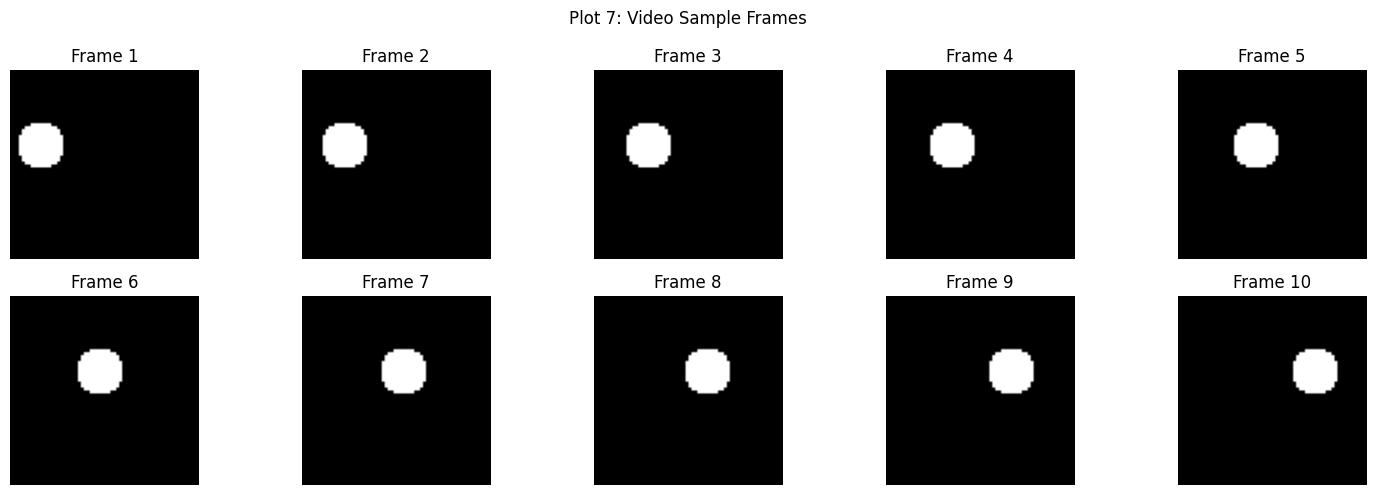

In [ ]:
# ==========================================
# PLOT 7: VIDEO SAMPLE FRAMES
# ==========================================

plt.figure(figsize=(15, 5))

# First video
sample_video = video_frames[0]

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(sample_video[i])

    plt.title("Frame " + str(i + 1))

    plt.axis("off")

plt.suptitle(
    "Plot 7: Video Sample Frames"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# PLOT 8: VIDEO TRAINING AND VALIDATION
# CURVES
# ==========================================

import matplotlib.pyplot as plt

# -------------------------------
# Accuracy
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    video_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    video_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Plot 8: Video Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


# -------------------------------
# Loss
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    video_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    video_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Plot 8: Video Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

NameError: name 'video_history' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# ==========================================
# STEP 1: CNN FEATURE EXTRACTION
# ==========================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load MobileNetV2 without classification layer
cnn_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze CNN
cnn_model.trainable = False

print("CNN loaded successfully.")

print("CNN feature dimension:",
      cnn_model.output_shape[-1])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN loaded successfully.
CNN feature dimension: 1280


In [ ]:
# ==========================================
# STEP 2: EXTRACT FEATURES FROM VIDEOS
# ==========================================

# Number of videos
num_videos = video_frames.shape[0]

# Store features
video_X = []

for i in range(num_videos):

    # Get 10 frames of one video
    frames = video_frames[i]

    # Resize 64x64 -> 224x224
    frames_resized = tf.image.resize(
        frames,
        (224, 224)
    )

    # MobileNetV2 preprocessing
    frames_resized = preprocess_input(
        frames_resized
    )

    # Extract CNN features
    features = cnn_model.predict(
        frames_resized,
        verbose=0
    )

    # features = (10, 1280)
    video_X.append(features)


# Convert list to NumPy array
video_X = np.array(video_X)

# Labels
video_y = video_labels


print("Video feature shape:", video_X.shape)
print("Video label shape:", video_y.shape)

Video feature shape: (90, 10, 1280)
Video label shape: (90,)


In [ ]:
# ==========================================
# STEP 3: CREATE AND TRAIN VIDEO LSTM
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

# Train-test split
X_video_train, X_video_test, y_video_train, y_video_test = train_test_split(
    video_X,
    video_y,
    test_size=0.20,
    random_state=42,
    stratify=video_y
)

print("Training data:", X_video_train.shape)
print("Testing data:", X_video_test.shape)


# Number of classes
num_classes = len(np.unique(video_y))


# Create LSTM model
video_model = Sequential([
    LSTM(
        32,
        input_shape=(10, 1280)
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])


# Compile
video_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Train
video_history = video_model.fit(
    X_video_train,
    y_video_train,

    validation_split=0.20,

    epochs=15,

    batch_size=8,

    verbose=1
)

print("Video LSTM training completed!")

Training data: (72, 10, 1280)
Testing data: (18, 10, 1280)
Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.4035 - loss: 1.2164 - val_accuracy: 0.2667 - val_loss: 1.1658
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2632 - loss: 1.1527 - val_accuracy: 0.2667 - val_loss: 1.1314
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3509 - loss: 1.1146 - val_accuracy: 0.3333 - val_loss: 1.1139
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3684 - loss: 1.0916 - val_accuracy: 0.2667 - val_loss: 1.1092
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3509 - loss: 1.1013 - val_accuracy: 0.2667 - val_loss: 1.1091
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2807 - loss: 1.1053 - val_accuracy: 0.2667 - val_loss: 1.1043
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3509 - loss: 1.1017 - val_accuracy: 0.3333 - val_loss: 1.1005
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3509 - loss: 1.0947 - val_accuracy: 0.3333 - val_loss: 1.0944
Epoch 9/15


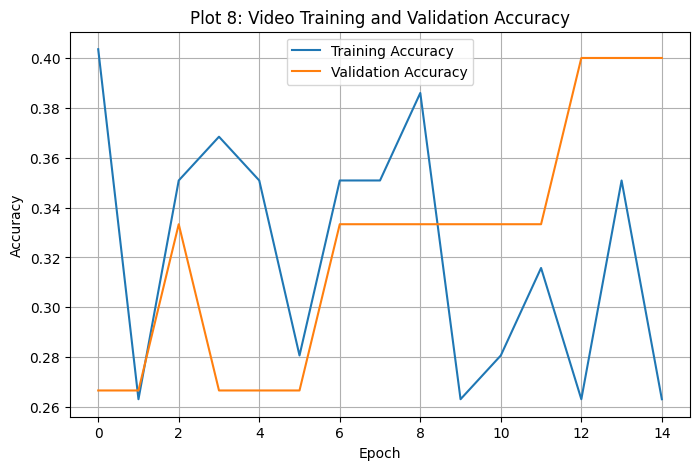

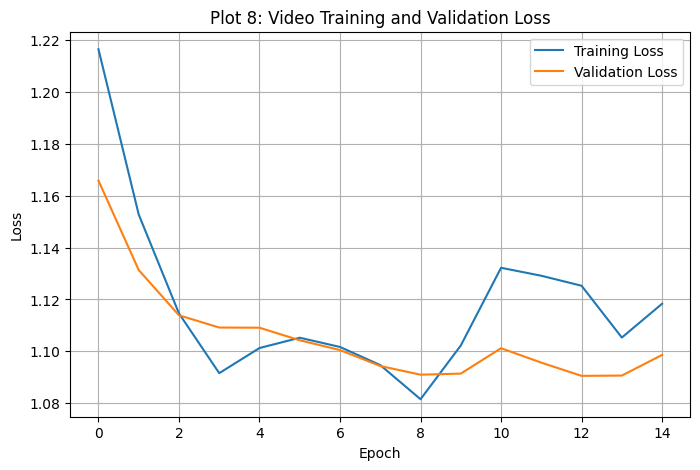

In [ ]:
# ==========================================
# PLOT 8: VIDEO TRAINING AND VALIDATION
# ==========================================

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    video_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    video_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Plot 8: Video Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    video_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    video_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 8: Video Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


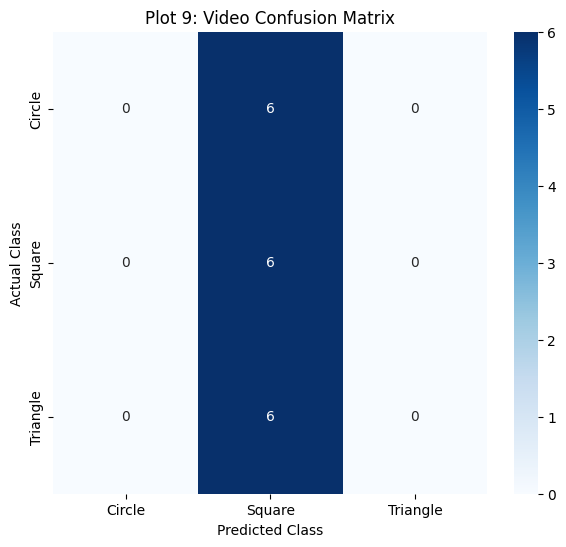

Classification Report:
              precision    recall  f1-score   support

      Circle       0.00      0.00      0.00         6
      Square       0.33      1.00      0.50         6
    Triangle       0.00      0.00      0.00         6

    accuracy                           0.33        18
   macro avg       0.11      0.33      0.17        18
weighted avg       0.11      0.33      0.17        18



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==========================================
# PLOT 9: VIDEO CONFUSION MATRIX
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Predict
predictions = video_model.predict(
    X_video_test
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)


# Confusion matrix
cm = confusion_matrix(
    y_video_test,
    predicted_classes
)


# Plot
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Plot 9: Video Confusion Matrix")

plt.show()


# Classification report
print("Classification Report:")

print(
    classification_report(
        y_video_test,
        predicted_classes,
        target_names=class_names
    )
)